In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation as LDA, NMF # Note importing of two topic modelers

sns.set_theme(style="white")
pio.renderers.default = 'iframe'

In [2]:
OHCO = ['book_id', 'chap_num', 'para_num', 'sent_num', 'token_num']
PARA = OHCO[:3]
CHAP = OHCO[:2]
BOOK = OHCO[:1]
BAG = CHAP

In [3]:
CORPUS = pd.read_csv("/kaggle/input/notebooks/isabellouisedelgado/text-as-data-final-project-corpus/GothicNovels_CORPUS.csv").set_index(OHCO)
LIB = pd.read_csv("/kaggle/input/notebooks/isabellouisedelgado/text-as-data-final-project-corpus/GothicNovels_LIB.csv").set_index("book_id")

In [4]:
DOCS = CORPUS[CORPUS.pos.str.match(r'^NNS?$')]\
    .groupby(BAG).term_str\
    .apply(lambda x: ' '.join(map(str,x)))\
    .to_frame()\
    .rename(columns={'term_str':'doc_str'})

In [5]:
from sklearn.feature_extraction import text

my_stop_words = list(text.ENGLISH_STOP_WORDS.union(['yes']))

In [6]:
count_engine = CountVectorizer(max_df=.9, min_df=10, stop_words=my_stop_words)
count_model = count_engine.fit_transform(DOCS.doc_str)
TERMS = count_engine.get_feature_names_out()
VOCAB = pd.DataFrame(index=TERMS)
VOCAB.index.name = 'term_str'
DTM = pd.DataFrame(count_model.toarray(), index=DOCS.index, columns=TERMS)
DTM

absence  accents  accident  account  accounts  \
book_id  chap_num                                                  
43       9               0        0         1        0         0   
         10              1        0         0        0         0   
         11              0        0         0        0         0   
         12              0        0         0        0         0   
         13              0        0         0        0         1   
...                    ...      ...       ...      ...       ...   
20180856 5               0        0         0        1         0   
         6               0        0         0        0         0   
         7               0        0         0        1         0   
         8               0        0         0        0         0   
         9               0        0         0        0         0   

                   acquaintance  acquiescence  act  action  actions  ...  \
book_id  chap_num                                                    ...   
43       9                    1             0    0       0        0  ...   
         10                   0             0    0       0        0  ...   
         11                   0             0    0       0        0  ...   
         12                   0             0    0       1        0  ...   
         13                   0             0    0       0        0  ...   
...                         ...           ...  ...     ...      ...  ...   
20180856 5                    0             0    0       0        0  ...   
         6                    0             0    2       0        0  ...   
         7                    0             0    1       0        0  ...   
         8                    0             0    0       0        0  ...   
         9                    0             0    1       0        0  ...   

                   wretchedness  wrist  writing  yard  ye  year  years  \
book_id  chap_num                                                        
43       9                    0      0        0     0   0     0      1   
         10                   0      0        0     0   0     0      2   
         11                   0      0        0     0   0     0      0   
         12                   0      0        0     0   0     1      1   
         13                   0      0        1     1   0     0      0   
...                         ...    ...      ...   ...  ..   ...    ...   
20180856 5                    0      0        4     0   0     0      2   
         6                    0      1        0     0   0     0      0   
         7                    0      0        2     0   0     0      3   
         8                    0      0        0     0   0     1      0   
         9                    0      0        0     0   0     0      1   

                   yesterday  youth  zeal  
book_id  chap_num                          
43       9                 0      1     0  
         10                0      0     0  
         11                0      0     0  
         12                1      0     0  
         13                0      0     0  
...                      ...    ...   ...  
20180856 5                 1      0     0  
         6                 0      0     0  
         7                 0      0     0  
         8                 0      0     0  
         9                 0      0     0  

[119 rows x 1567 columns]

In [7]:
count_engine = CountVectorizer(max_df=.9, min_df=10, stop_words=my_stop_words)
count_model = count_engine.fit_transform(DOCS.doc_str)
TERMS = count_engine.get_feature_names_out()
VOCAB = pd.DataFrame(index=TERMS)
VOCAB.index.name = 'term_str'
DTM = pd.DataFrame(count_model.toarray(), index=DOCS.index, columns=TERMS)
DTM

absence  accents  accident  account  accounts  \
book_id  chap_num                                                  
43       9               0        0         1        0         0   
         10              1        0         0        0         0   
         11              0        0         0        0         0   
         12              0        0         0        0         0   
         13              0        0         0        0         1   
...                    ...      ...       ...      ...       ...   
20180856 5               0        0         0        1         0   
         6               0        0         0        0         0   
         7               0        0         0        1         0   
         8               0        0         0        0         0   
         9               0        0         0        0         0   

                   acquaintance  acquiescence  act  action  actions  ...  \
book_id  chap_num                                                    ...   
43       9                    1             0    0       0        0  ...   
         10                   0             0    0       0        0  ...   
         11                   0             0    0       0        0  ...   
         12                   0             0    0       1        0  ...   
         13                   0             0    0       0        0  ...   
...                         ...           ...  ...     ...      ...  ...   
20180856 5                    0             0    0       0        0  ...   
         6                    0             0    2       0        0  ...   
         7                    0             0    1       0        0  ...   
         8                    0             0    0       0        0  ...   
         9                    0             0    1       0        0  ...   

                   wretchedness  wrist  writing  yard  ye  year  years  \
book_id  chap_num                                                        
43       9                    0      0        0     0   0     0      1   
         10                   0      0        0     0   0     0      2   
         11                   0      0        0     0   0     0      0   
         12                   0      0        0     0   0     1      1   
         13                   0      0        1     1   0     0      0   
...                         ...    ...      ...   ...  ..   ...    ...   
20180856 5                    0      0        4     0   0     0      2   
         6                    0      1        0     0   0     0      0   
         7                    0      0        2     0   0     0      3   
         8                    0      0        0     0   0     1      0   
         9                    0      0        0     0   0     0      1   

                   yesterday  youth  zeal  
book_id  chap_num                          
43       9                 0      1     0  
         10                0      0     0  
         11                0      0     0  
         12                1      0     0  
         13                0      0     0  
...                      ...    ...   ...  
20180856 5                 1      0     0  
         6                 0      0     0  
         7                 0      0     0  
         8                 0      0     0  
         9                 0      0     0  

[119 rows x 1567 columns]

In [8]:
n_topics = 20
max_iter = 100
n_top_terms = 9
TNAMES = [f"T{str(x).zfill(len(str(n_topics)))}" for x in range(n_topics)]
model_type = 'lda'


In [9]:
if model_type == 'lda':
    topic_engine = LDA(n_components=n_topics, max_iter=max_iter)
elif model_type == 'nmf':
    topic_engine = NMF(n_components=n_topics, max_iter=max_iter)
topic_model = topic_engine.fit_transform(count_model)

In [10]:
colors = "YlGnBu"

## LDA THETA

In [11]:
THETA = pd.DataFrame(topic_model, index=DOCS.index, columns=TNAMES)
THETA.columns.name = 'topic_id'
THETA.sample(10).T.style.background_gradient(cmap=colors, axis=None)

book_id,20180856,175,12122,3268,20180856,345,41445,3268,41445,345
chap_num,7,19,1,1,2,14,27,2,3,7
topic_id,,,,,,,,,,
T00,0.000067,0.000266,0.000255,0.000005,0.000076,0.000078,0.816850,0.000005,0.082121,0.000076
T01,0.000067,0.000266,0.000255,0.000005,0.004006,0.000078,0.000044,0.000005,0.001923,0.000076
T02,0.000067,0.000266,0.249679,0.011767,0.000076,0.000078,0.000044,0.058307,0.001923,0.000076
T03,0.000067,0.000266,0.000255,0.000005,0.000076,0.000078,0.000044,0.000005,0.438137,0.000076
T04,0.000067,0.000266,0.000255,0.000005,0.000076,0.000078,0.000044,0.000005,0.001923,0.000076
T05,0.000067,0.000266,0.000255,0.000005,0.000076,0.000078,0.000044,0.000005,0.208580,0.000076
T06,0.000067,0.000266,0.000255,0.000005,0.000076,0.000078,0.000044,0.000005,0.001923,0.000076
T07,0.000067,0.188078,0.351153,0.041443,0.000076,0.573888,0.066616,0.000005,0.001923,0.000076


## LDA PHI

In [12]:
PHI = pd.DataFrame(topic_engine.components_, columns=TERMS, index=TNAMES)
PHI.index.name = 'topic_id'
PHI.columns.name = 'term_str'
PHI.T.sample(10).T.style.background_gradient(cmap=colors, axis=None)

term_str,use,interruption,assurance,apartments,hour,answer,board,mansion,youth,crucifix
topic_id,,,,,,,,,,
T00,0.050000,0.050000,0.050000,0.050000,6.472864,0.050000,1.378915,0.050000,1.642449,0.050000
T01,1.595138,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000
T02,11.900117,0.050000,4.490560,5.311496,61.550501,26.323674,0.050000,0.050000,111.392809,0.050000
T03,0.050000,0.050000,0.050000,0.050000,3.750215,5.027109,12.299109,0.050000,0.050000,0.050000
T04,3.277161,0.050000,0.050000,0.050000,2.830783,0.050000,0.050000,0.050000,11.220964,0.050000
T05,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000
T06,0.050000,0.050000,0.050000,0.050000,1.022134,0.050000,0.050000,0.050000,1.050000,0.050000
T07,28.547429,1.274284,7.916240,0.050000,55.033363,31.131266,0.050000,3.307041,4.950791,10.626397
T08,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000


## LDA TOPIC - Top 5 words and best-guess labels for topic five topics by mean document weight

In [13]:
TOPICS = PHI.stack().groupby('topic_id')\
    .apply(lambda x: ' '.join(x.sort_values(ascending=False).head(n_top_terms).reset_index().term_str))\
    .to_frame('top_terms')
TOPICS

,top_terms
topic_id,
T00,life feelings misery day heart death ice happi...
T01,uncle death eye mind story street end key mother
T02,son father friend heart lord family apartment ...
T03,box ship water men river storm moment sunrise ...
T04,cottage wood day night pleasure sun food morni...
T05,nature years mother health friend feelings unc...
T06,angel police carriage commissary brother gentl...
T07,hand face room door way night things friend heart
T08,arguments hairs fun motionless reach instance ...


## LDA + PCA Visualization

# Riff 1

In [14]:
TITLES = {
    43:       'DR JEKYLL AND MR HYDE',
    175:      'THE PHANTOM OF THE OPERA',
    345:      'DRACULA',
    696:      'CASTLE OF OTRANTO',
    1952:     'THE YELLOW WALLPAPER',
    3268:     'THE MYSTERIES OF UDOLPHO',
    5182:     'THE OLD ENGLISH BARON',
    6087:     'THE VAMPYRE',
    12122:    'THE MONKEYS PAW',
    41445:    'FRANKENSTEIN',
    53685:    'MELMOTH THE WANDERER',
    20180856: 'THE HAUNTING OF HILL HOUSE',
}

In [15]:
THETA = THETA.rename(index=TITLES, level='book_id')

In [16]:
TOPIC_BOOK = THETA.groupby('book_id').mean() #.T.join(TOPICS[['top_terms','doc_weight_sum','term_freq']])
TOPIC_BOOK.T.style.background_gradient(axis=0, cmap="YlGnBu")

book_id,CASTLE OF OTRANTO,DR JEKYLL AND MR HYDE,DRACULA,FRANKENSTEIN,MELMOTH THE WANDERER,THE HAUNTING OF HILL HOUSE,THE MONKEYS PAW,THE MYSTERIES OF UDOLPHO,THE OLD ENGLISH BARON,THE PHANTOM OF THE OPERA,THE VAMPYRE,THE YELLOW WALLPAPER
topic_id,,,,,,,,,,,,
T00,0.012736,0.022440,0.002597,0.318449,0.008226,0.004234,0.000300,0.000005,0.000008,0.006686,0.153324,0.000085
T01,0.000061,0.075213,0.003990,0.007182,0.066970,0.000518,0.000300,0.000005,0.000008,0.044987,0.028673,0.000085
T02,0.701573,0.115136,0.007608,0.032107,0.086670,0.021256,0.083441,0.057734,0.999856,0.006731,0.129465,0.000085
T03,0.000061,0.014023,0.042066,0.023537,0.166385,0.002709,0.000300,0.000005,0.000008,0.007016,0.000214,0.000085
T04,0.000061,0.000345,0.000081,0.107321,0.001978,0.003692,0.000300,0.000005,0.000008,0.002578,0.000214,0.000085
T05,0.000061,0.000345,0.000081,0.057139,0.000083,0.000073,0.000300,0.000005,0.000008,0.000187,0.000214,0.000085
T06,0.000061,0.000345,0.000081,0.000215,0.000083,0.000073,0.000300,0.000005,0.000008,0.026111,0.000214,0.000085
T07,0.000061,0.492048,0.659806,0.029872,0.037690,0.048461,0.490564,0.011322,0.000008,0.177640,0.289647,0.476841
T08,0.000061,0.000345,0.000081,0.000215,0.000083,0.000073,0.000300,0.000005,0.000008,0.000187,0.000214,0.000085


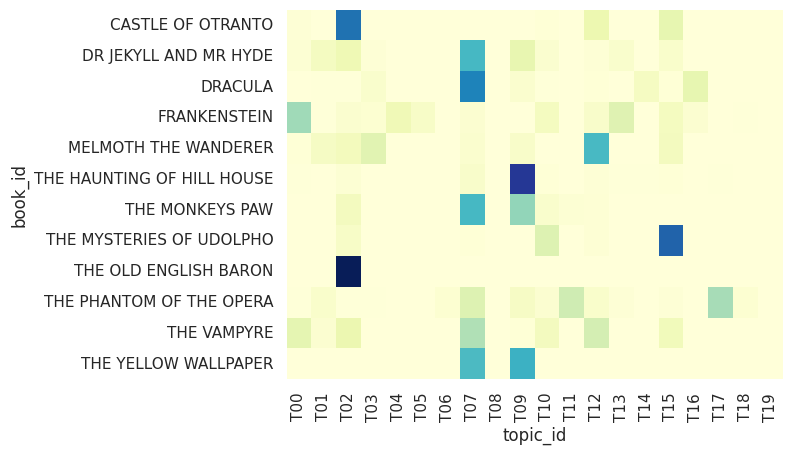

In [17]:
sns.heatmap(TOPIC_BOOK, cmap="YlGnBu", cbar=None)
plt.show()